# fedwater V0 — the whole pipeline, narrated

From a water network to a validated answer about federated drift under
dependence. **Incremental construction**: each stage exists because the one
before it proved something — and each method earned its place by the failure
of the one below it.

```
 simulation                       federated learning
 ----------                       ------------------
 network_prep (dependence dial)   fl_preprocessing (no-leakage scaling)
   -> urban_scenario (drift GT)     -> fl_training (FPL + AER prototypes)
   -> demand_synthesis (sqrt-N)     -> drift_detection (delta_first/roll)
   -> hydraulics (EPANET)           -> dependence_detection (3 budgets)
   -> sensing (client CSVs)         -> drift_attribution (ladder C0..C4)
   -> sim_validation (hard checks)  -> label_factory -> automl
   -> dependence_oracle (battery)
```
Every claim below is read from **catalog artifacts** produced by
`kedro run` / `--pipeline fl|dependence_detection|drift_attribution|label_factory|automl`.

In [3]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, matplotlib as mpl
import numpy as np, pandas as pd

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mpl.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True})
CLR = dict(zip([f"District_{x}" for x in "ABCDE"],
               ["#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc"]))

def art(rel, base=PROJECT, **kw):
    p = Path(base) / rel
    if not p.exists():
        return None
    return pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p, **kw)

ISO = Path("/tmp/fedwater_iso")   # regenerate: clone + coupling.variant=isolated
if not ISO.exists():
    print("NOTE: isolated-world clone not found — contrast panels will be "
          "skipped. Regenerate per README (clone + override + kedro run).")
print("project:", PROJECT)

NOTE: isolated-world clone not found — contrast panels will be skipped. Regenerate per README (clone + override + kedro run).
project: C:\Users\arthu\USPy\10_Mestrado\fedWater


## Stage 1 — a world you can trust

The simulator was rebuilt around invariants, not hopes: volume-exact demand
synthesis (the legacy code delivered ~24x less water than nominal), a
peak-feasibility-calibrated anchor, and **crowd smoothing that emerges from
aggregation** (sqrt-N law) instead of being injected. Hard physics checks run
*inside* the pipeline — a dataset that fails mass balance cannot exist.
Routine sanity: re-read the validation report that shipped with the data.

In [2]:
val = art("data/08_reporting/validation_report.csv")
print(val.to_string(index=False))
assert val[val["hard"]]["passed"].all(), "hard physics checks must hold"
pf = val[val["check"].str.startswith("V6_peak_factor[")].set_index("check")["value"]
assert pf["V6_peak_factor[low]"] > pf["V6_peak_factor[high]"], "sqrt-N ordering"
print("\nOK: mass balance, pressure band, volume exactness, emergent smoothing")

                   check     value  hard  passed
         V1_mass_balance  0.000000  True    True
     V2_volume_exactness  0.000005  True    True
       V3_pressure_floor 11.942286  True    True
  V4_pressure_band_share  1.000000 False    True
  V5_unit_m3_month[high] 29.000000 False    True
   V5_unit_m3_month[low]  9.250000 False    True
  V6_peak_factor_in_band  1.000000 False    True
V6_smoothing_low_gt_high  0.825677 False    True
    V6_peak_factor[high]  1.455698 False    True
     V6_peak_factor[low]  2.281375 False    True
  V6_peak_factor[medium]  1.635668 False    True

OK: mass balance, pressure band, volume exactness, emergent smoothing


## Stage 2 — drift detection works... and fails for the right reason

FPL prototypes over an AER autoencoder (7 correctness fixes vs the legacy
code, most importantly: the latent IS the encoder bottleneck, prototypes come
from a clean eval pass, scalers never see the future). On the **isolated**
world the detector is clean; on the **coupled** baseline every client's
prototypes track the *system* state that District D's growth imposes through
the shared pipes — the dissertation's problem, reproduced end-to-end.

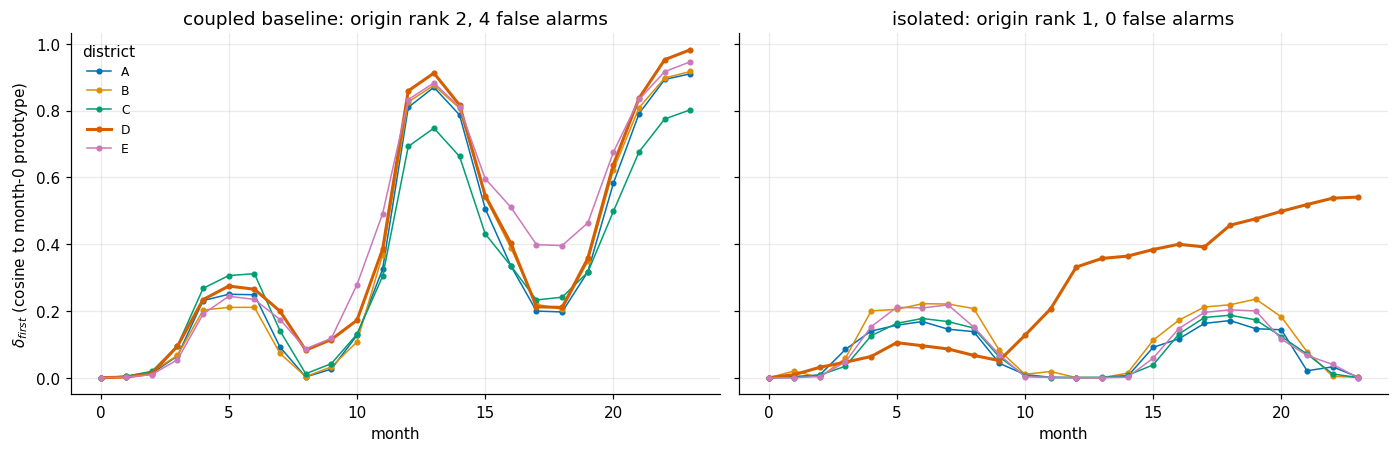

In [3]:
sig_b = art("data/07_model_output/drift_signals.csv")
rep_b = art("data/08_reporting/drift_report.csv")
gt = art("data/03_primary/gt_drift_schedule.csv", dtype={"node": str})
assert gt["district"].nunique() == 1, "one drift origin in this world"
panels = [("coupled baseline", sig_b, rep_b)]
if ISO.exists():
    panels.append(("isolated", art("data/07_model_output/drift_signals.csv", ISO),
                   art("data/08_reporting/drift_report.csv", ISO)))
fig, axes = plt.subplots(1, len(panels), figsize=(6.3 * len(panels), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, (name, sig, rep) in zip(axes, panels):
    for c, g in sig.groupby("client"):
        ax.plot(g["month"], g["delta_first"], "o-", ms=3, color=CLR[c],
                lw=2 if c == gt["district"].iloc[0] else 1, label=c[-1])
    s = rep[rep.client == "__summary__"].iloc[0]
    ax.set(xlabel="month", title=f"{name}: origin rank {int(s['rank'])}, "
           f"{int(s['false_alarms'])} false alarms")
axes[0].set_ylabel(r"$\delta_{first}$ (cosine to month-0 prototype)")
axes[0].legend(frameon=False, fontsize=8, title="district")
plt.show()

## Stage 3 — dependence: detected, quantified, validated on a dial

Three communication budgets (P prototypes / T latent trajectories / R
centralized oracle). Headline numbers: RV falls **0.64 -> 0.40 -> 0.008**
across baseline / partial-50 / isolated with significant pairs
**10/10 -> 10/10 -> 0/10** — and **partial RV recovers the physical boundary
structure at AUROC 1.00**, above every centralized raw-data method (0.68).
Sanity: monotonicity asserted, not admired.

baseline Level-T mean |stat|: {'partial_rv': 0.03, 'pc1_lagged_xcorr': 0.79, 'rv': 0.637, 'trajectory_dcor': 0.765}


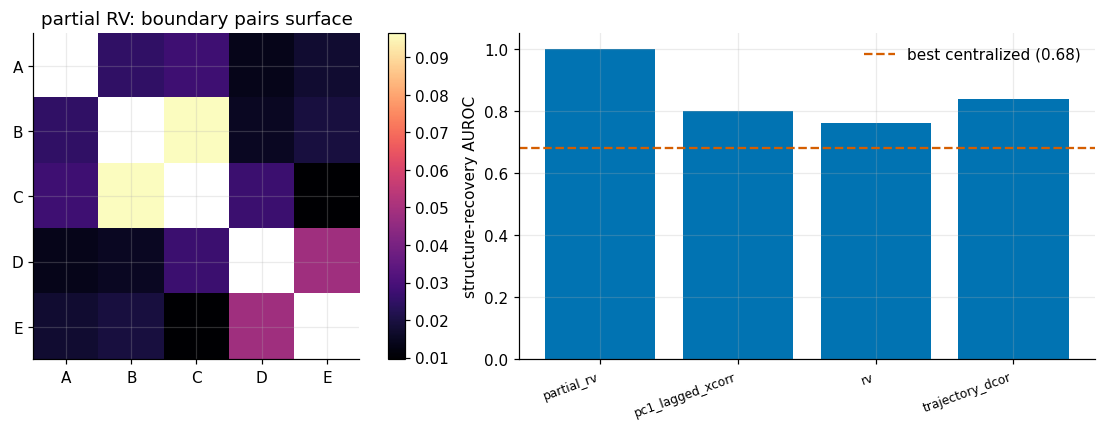

dial check OK: rv 0.637 (coupled) vs 0.008 (isolated); significant pairs 10/10 vs 0/10


In [4]:
dep = art("data/08_reporting/client_dependence.csv")
ev = art("data/08_reporting/dependence_evaluation.csv")
t = dep[dep.level == "T"]
print("baseline Level-T mean |stat|:",
      t.groupby("method")["statistic"].apply(lambda s: s.abs().mean()).round(3).to_dict())
sr = ev[(ev.evaluation == "structure_recovery") & (ev.kind == "aer_latent")]
cent_best = art("data/08_reporting/gt_structure_recovery.csv")["auroc"].max()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
M = pd.DataFrame(np.nan, list("ABCDE"), list("ABCDE"))
for _, r in t[t.method == "partial_rv"].iterrows():
    a, b = r.district_a[-1], r.district_b[-1]
    M.loc[a, b] = M.loc[b, a] = abs(r.statistic)
im = axes[0].imshow(M, cmap="magma")
axes[0].set_xticks(range(5), list("ABCDE")); axes[0].set_yticks(range(5), list("ABCDE"))
axes[0].set_title("partial RV: boundary pairs surface"); plt.colorbar(im, ax=axes[0])
axes[1].bar(range(len(sr)), sr["auroc"], color="#0173b2")
axes[1].axhline(cent_best, color="#d55e00", ls="--",
                label=f"best centralized ({cent_best:.2f})")
axes[1].set_xticks(range(len(sr)), sr["method"], rotation=20, ha="right", fontsize=8)
axes[1].set(ylabel="structure-recovery AUROC"); axes[1].legend(frameon=False)
plt.show()
if ISO.exists():
    iso_rv = art("data/08_reporting/client_dependence.csv", ISO)
    iso_rv = iso_rv[(iso_rv.level == "T") & (iso_rv.method == "rv")]
    base_rv = t[t.method == "rv"]["statistic"].abs().mean()
    assert base_rv > 5 * iso_rv["statistic"].abs().mean(), "dial monotonicity"
    print(f"dial check OK: rv {base_rv:.3f} (coupled) vs "
          f"{iso_rv['statistic'].abs().mean():.3f} (isolated); "
          f"significant pairs {int((t[t.method=='rv'].q_value<.05).sum())}/10 vs "
          f"{int((iso_rv.q_value<.05).sum())}/10")

## Stage 4 — adversarial example I: the exogenous-driver confound

Every dependence statistic in this project runs on month/phase/weekday
residualized signals. Why: clients that are **independent by construction**
still share seasonality (all clients share the weather). Demonstration on
synthetic independent series with a common seasonal component — naive
correlation reports strong "dependence"; residualization kills it. The same
check on the real isolated world drove the weekday fix (spurious 10/10
significant -> clean 0/10).

In [5]:
rng = np.random.default_rng(0)
months = np.repeat(np.arange(6), 240)
season = np.repeat(rng.normal(0, 3, 6), 240)
a = season + rng.normal(size=len(months))         # independent clients,
b = season + rng.normal(size=len(months))         # shared season only
def resid(x):
    df = pd.DataFrame({"x": x, "m": months})
    return (df["x"] - df.groupby("m")["x"].transform("mean")).to_numpy()
r_naive = np.corrcoef(a, b)[0, 1]
r_resid = np.corrcoef(resid(a), resid(b))[0, 1]
print(f"|r| naive = {abs(r_naive):.3f}   |r| residualized = {abs(r_resid):.3f}")
assert abs(r_naive) > 0.5 > abs(r_resid), "the confound and its cure"

|r| naive = 0.563   |r| residualized = 0.011


## Stage 5 — adversarial example II: the corrector ladder and the
coherence wall

C0..C4 separate local drift from network state at increasing sophistication.
On a **planted world with an exogenous common mode** (below, heterogeneous
per-client gains) the C4 factor loop wins and its weights identify the
drifter. On the **real coupled network** every analytic corrector fails —
because the drifted district's signature and the network's response are the
*same physical event*: the sparse and low-rank components are maximally
coherent, violating the identifiability every symmetric decomposition needs.
That measured failure is the motivation for the learned rungs.

In [6]:
from fedwater.pipelines.drift_attribution.nodes import (
    apply_correctors, evaluate_correctors)
# --- planted adversarial world: exogenous common mode, per-client gains ---
CL = ["C_A", "C_B", "C_C", "C_D"]
rng = np.random.default_rng(21); n_m, dim = 20, 10
gains = dict(zip(CL, [0.5, 1.0, 1.8, 0.8]))
steps = rng.normal(0, 1, (n_m, dim)); steps[:10] *= 0.1; steps[10:] *= 4
common = np.cumsum(steps, axis=0); drift_dir = rng.normal(size=dim) * 5
rows, lat_rows = [], []
for c in CL:
    base = rng.normal(size=dim); eps = np.zeros((n_m, dim))
    for m in range(1, n_m): eps[m] = .3 * eps[m-1] + .05 * rng.normal(size=dim)
    for m in range(n_m):
        p = base + gains[c]*common[m] + eps[m] + (drift_dir if (c=="C_D" and m>=10) else 0)
        rows.append(dict(round=0, client=c, month=m,
                         **{f"f{i}": v for i, v in enumerate(p)}))
    L = rng.normal(size=(n_m*20, dim))
    for w in range(len(L)):
        lat_rows.append(dict(district=c, kind="aer_latent", window=w*4,
                             month=w//20, **{f"f{i}": v for i, v in enumerate(L[w])}))
dep_stub = pd.DataFrame([dict(level="T", kind="aer_latent", district_a=x,
    district_b=y, method="partial_rv", statistic=.5, p_value=.001,
    q_value=.001, comm_floats_per_client=1, extra=np.nan)
    for i, x in enumerate(CL) for y in CL[i+1:]])
gt_p = pd.DataFrame({"node": ["1"], "district": ["C_D"], "drift_month": [10],
                     "to_income": ["high"], "to_density": ["low"]})
FLcfg = {"attribution": {"reference_months": 6, "ridge_lambda": 1.0,
                         "mask_q_threshold": .05, "loop_iterations": 6},
         "drift": {"reference_months": 6, "k_sigma": 3.0, "persistence": 3}}
sig_p, _, diag = apply_correctors(pd.DataFrame(rows), pd.DataFrame(lat_rows),
                                  dep_stub, FLcfg)
rep_p = evaluate_correctors(sig_p, gt_p, FLcfg)
planted = rep_p[rep_p.client == "__summary__"].set_index("corrector")["rank"]
real = art("data/08_reporting/corrector_ladder_report.csv")
real = real[real.client == "__summary__"].set_index("corrector")["rank"]
tbl = pd.DataFrame({"planted (exogenous)": planted, "real (endogenous)": real})
print(tbl.to_string())
assert planted["C4_sparse_loop"] == 1 and real["C4_sparse_loop"] > 1
w_fin = diag[diag.iteration == diag.iteration.max()].set_index("client")["weight"]
print("\nplanted world — C4 weights identify the drifter:",
      w_fin.round(2).to_dict(), "-> min:", w_fin.idxmin())

                     planted (exogenous)  real (endogenous)
corrector                                                  
C0_uncorrected                         2                  2
C1_peer_zscore                         2                  2
C2_median_removal                      3                  3
C2b_loo_median                         3                  5
C3_peer_pred_full                      4                  4
C3_peer_pred_masked                    4                  4
C4_sparse_loop                         1                  4

planted world — C4 weights identify the drifter: {'C_A': 0.5, 'C_B': 0.5, 'C_C': 0.86, 'C_D': 0.0} -> min: C_D


## Stage 6 — the label factory and the learned rungs

Since analytics hit the coherence wall, the distinction must be learned from
**signatures** (flow-vs-pressure composition, direction of influence,
timing). The factory generates randomized worlds — each a full validated
pipeline run — and extracts supervised tables with physical ground truth as
labels. Training discipline: **leave-one-world-out**, held-out coupling
variants, later a second topology. The 2-world demo below correctly reports
chance AUROC — the honest floor before scaling `n_worlds`.

In [7]:
specs = art("data/05_model_input/world_specs.csv", dtype={"drift_seed_node": str})
lp = art("data/05_model_input/labeled_pairs.parquet")
lc = art("data/05_model_input/labeled_clients.parquet")
am = art("data/08_reporting/automl_report.csv")
print(specs.to_string(index=False))
assert lc.groupby("world")["label_is_origin"].sum().eq(1).all(), "one origin/world"
print(f"\nlabeled_pairs {lp.shape} | labeled_clients {lc.shape}")
print(am[am.selected][["model", "cv_auroc", "n_folds", "n_rows",
                       "n_features"]].to_string(index=False))
print("\nAUROC 0.5 at 2 worlds is the validation design working — "
      "scale n_worlds (cache-or-run, ~3 min/world) for the real experiment.")

 world  world_seed  variant  close_fraction drift_district drift_seed_node drift_to_income  anchor_scale
     0       42898 baseline             0.0     District_A             108          medium          0.05
     1        5633  partial             0.3     District_C              73            high          0.04

labeled_pairs (20, 25) | labeled_clients (10, 18)
              model  cv_auroc  n_folds  n_rows  n_features
dependence_detector       0.5        2      20          19
   drift_attributor       0.5        2      10          13

AUROC 0.5 at 2 worlds is the validation design working — scale n_worlds (cache-or-run, ~3 min/world) for the real experiment.


## Where V0 ends and V1 begins

**Standing results:** physics-validated simulator with a dependence dial;
drift detection clean under independence and provably contaminated under
coupling; federated dependence detected (10/10 vs 0/10) and quantified
(RV 0.64 -> 0.40 -> 0.008); partial RV structure recovery AUROC 1.00 vs 0.68
centralized; the analytic corrector ladder's measured coherence failure; a
working label factory + grouped-validation AutoML harness.

**V1 gaps, in order:** scale the factory (20-40 worlds) and get the first
real learned-attributor result; a second network topology (the transfer test
that kills circularity); per-sensor-kind prototypes (cheap confirmation of
the coherence diagnosis); multi-drifter stress; the C5 episode store
(FPL-prototypes-as-memory). Each rung must beat the one below to earn its
complexity — that rule built everything above.